In [2]:
from google.colab import files
uploaded = files.upload()

Saving Clustering_Class.xlsx to Clustering_Class.xlsx


Libraries loaded successfully

Dataset loaded
  CustomerID  x1  x2
0         A1   2  10
1         A2   2   5
2         A3   8   4
3         A4   5   8
4         A5   7   5
5         A6   6   4
6         A7   1   2
7         A8   4   9

Dataset Summary
Total customers: 8
Missing values: 0

Statistics:
             x1         x2
count  8.000000   8.000000
mean   4.375000   5.875000
std    2.559994   2.799872
min    1.000000   2.000000
25%    2.000000   4.000000
50%    4.500000   5.000000
75%    6.250000   8.250000
max    8.000000  10.000000


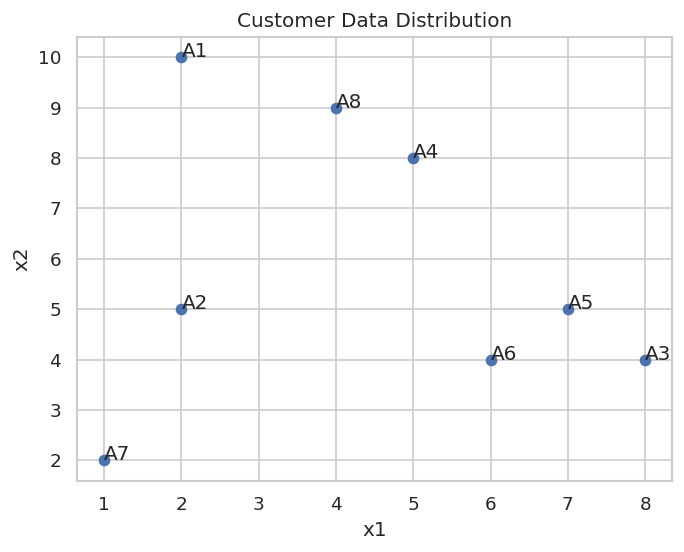


Data scaled successfully


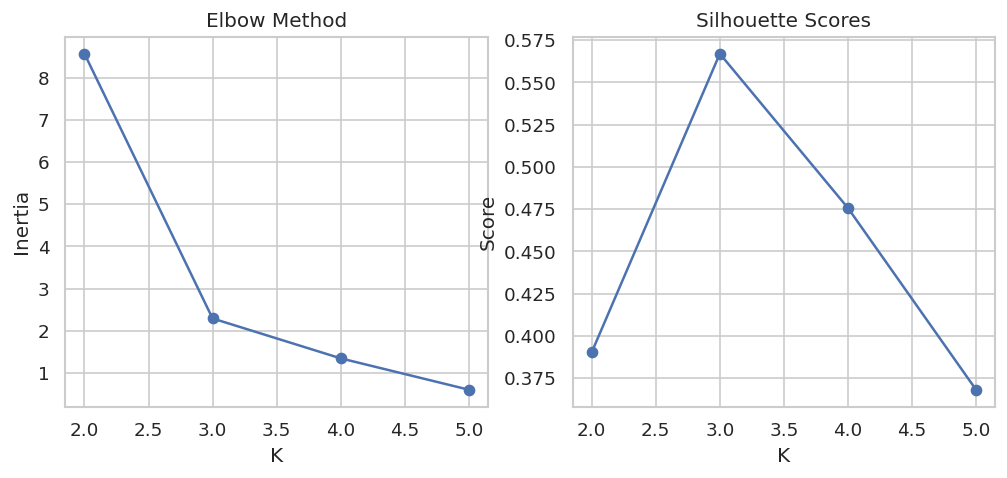


Cluster Assignments:
  CustomerID  x1  x2  Cluster
0         A1   2  10        1
1         A2   2   5        2
2         A3   8   4        0
3         A4   5   8        1
4         A5   7   5        0
5         A6   6   4        0
6         A7   1   2        2
7         A8   4   9        1


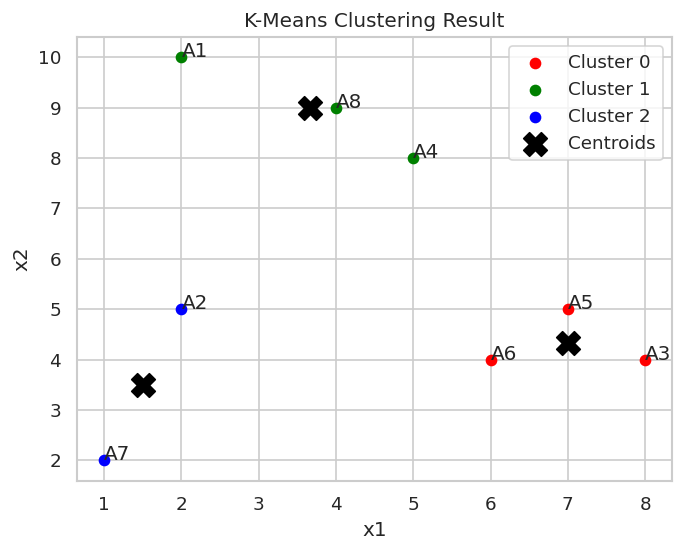


Average Silhouette Score: 0.5670103843363123


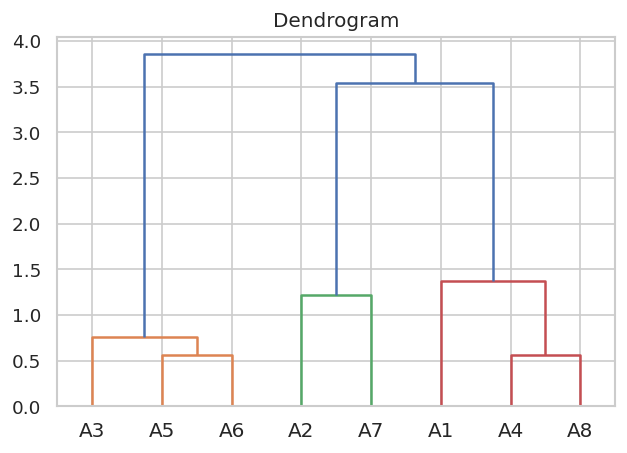

Hierarchical Clustering Score: 0.5670103843363123

Model Comparison
K-Means Score: 0.5670103843363123
Hierarchical Score: 0.5670103843363123

Final Summary
Total Customers: 8
Clusters formed: 3
Best Method: K-Means
Cluster 0: ['A3', 'A5', 'A6']
Cluster 1: ['A1', 'A4', 'A8']
Cluster 2: ['A2', 'A7']


In [8]:
# Customer Segmentation using K-Means Clustering
# Unsupervised Learning Project

# =========================
# Import Required Libraries
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

# Styling for plots
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

print("Libraries loaded successfully")


# =========================
# Load and Prepare Dataset
# =========================
# Upload Excel file in Colab before running this
df_raw = pd.read_excel("Clustering_Class.xlsx", header=None)

# Extract relevant rows (A1–A8)
df = df_raw.iloc[13:21, [0, 1, 2]].copy()
df.columns = ["CustomerID", "x1", "x2"]
df = df.reset_index(drop=True)

# Ensure numeric format
df["x1"] = pd.to_numeric(df["x1"])
df["x2"] = pd.to_numeric(df["x2"])

print("\nDataset loaded")
print(df)


# =========================
# Basic Data Overview
# =========================
print("\nDataset Summary")
print("Total customers:", len(df))
print("Missing values:", df.isnull().sum().sum())

print("\nStatistics:")
print(df[["x1", "x2"]].describe())


# =========================
# Initial Visualization
# =========================
plt.scatter(df["x1"], df["x2"])
for i in range(len(df)):
    plt.text(df["x1"][i], df["x2"][i], df["CustomerID"][i])
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Customer Data Distribution")
plt.show()


# =========================
# Feature Scaling
# =========================
X = df[["x1", "x2"]].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nData scaled successfully")


# =========================
# Elbow + Silhouette Method
# =========================
inertia_vals = []
sil_scores = []

k_values = range(2, 6)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)

    inertia_vals.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

# Plot results
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(k_values, inertia_vals, marker='o')
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("Inertia")

plt.subplot(1,2,2)
plt.plot(k_values, sil_scores, marker='o')
plt.title("Silhouette Scores")
plt.xlabel("K")
plt.ylabel("Score")

plt.show()


# =========================
# Apply K-Means (K=3)
# =========================
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

df["Cluster"] = labels

centroids_scaled = kmeans.cluster_centers_
centroids = scaler.inverse_transform(centroids_scaled)

print("\nCluster Assignments:")
print(df)


# =========================
# Visualization of Clusters
# =========================
colors = ["red", "green", "blue"]

for i in range(3):
    plt.scatter(df[df["Cluster"] == i]["x1"],
                df[df["Cluster"] == i]["x2"],
                color=colors[i],
                label=f"Cluster {i}")

# Plot centroids
plt.scatter(centroids[:,0], centroids[:,1],
            color="black", marker="X", s=200, label="Centroids")

for i in range(len(df)):
    plt.text(df["x1"][i], df["x2"][i], df["CustomerID"][i])

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("K-Means Clustering Result")
plt.legend()
plt.show()


# =========================
# Silhouette Analysis
# =========================
sample_values = silhouette_samples(X_scaled, labels)
avg_score = silhouette_score(X_scaled, labels)

print("\nAverage Silhouette Score:", avg_score)


# =========================
# Hierarchical Clustering
# =========================
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(6,4))
dendrogram(linked, labels=df["CustomerID"].values)
plt.title("Dendrogram")
plt.show()

hc = AgglomerativeClustering(n_clusters=3)
hc_labels = hc.fit_predict(X_scaled)

hc_score = silhouette_score(X_scaled, hc_labels)

print("Hierarchical Clustering Score:", hc_score)


# =========================
# Model Comparison
# =========================
km_score = silhouette_score(X_scaled, labels)

print("\nModel Comparison")
print("K-Means Score:", km_score)
print("Hierarchical Score:", hc_score)


# =========================
# Final Summary
# =========================
print("\nFinal Summary")
print("Total Customers:", len(df))
print("Clusters formed:", 3)
print("Best Method: K-Means")

for i in range(3):
    members = df[df["Cluster"] == i]["CustomerID"].tolist()
    print(f"Cluster {i}:", members)